# CIC-IDS-2017 Network Intrusion Dataset Attacker Classification 
### Flow Level Intrusion Detection

This notebook uses CIC-IDS-2017 flow data for 

### Attack Type Classification (Supervised) 
We will train a supervised classifer using labeled CIC-IDS traffic to predict attack categories
- Predict attack labels on new flow data
- Provide class probabilities
- Serve as baseline for future real honepot traffic classifiers. 

CIC-IDS2017 intrusion dataset:  
https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset  
This dataset contains labeled network traffic including both normal activity and multiple cyberattacks (brute force, DoS, infiltration), making it a common benchmark for intrusion detection research and anomaly analysis.

Information to download the dataset are in `machine-learning/data/READ.me`

Note: CIC-IDS is flow level, so it does not include password attemps or command level features

### Expected Inputs:
- CSV files with flow records from CIC-IDS 2017 dataset
- Each CSV contains label columns

### Outputs:
- Train / Val / Test splits 
- Trained Supervised Classifier
- Evaluation Metrics

We use Logistic Regression model from scikit-learn which is a linear classifier that predicts the probability of each attack case. The features used for training are all the numerical flow features from the dataset that help describe the network traffic behavior. 

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import joblib


### Preprocessing
- Load in CSV files from data and combine into one large data frame

In [4]:
#path for network intrustion data
NETWORK_DIR = Path("../data/Kaggle CIC-IDS-2017")
csv_files = sorted(NETWORK_DIR.glob("*.pcap_ISCX.csv"))

#prints found CSV files
print("CSV files:", len(csv_files))
for f in csv_files[:8]:
    print(" -", f.name)

#combines all dataset into one large data frame
dfs= []
for f in csv_files:
    df= pd.read_csv(f, low_memory=False)
    df["_source_file"]= f.name
    dfs.append(df)

net_df= pd.concat(dfs, ignore_index=True)
print("Network shape:", net_df.shape)
print("Columns:", len(net_df.columns))
#Network shape: (2830743, 79)
#Columns: 79
#show some rows of the dataset 
#net_df.head()
net_df.sample(10)

CSV files: 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
Network shape: (2830743, 80)
Columns: 80


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,_source_file
1925820,53,50655,2,2,86,204,43,43,43.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Tuesday-WorkingHours.pcap_ISCX.csv
2262483,80,1,2,0,0,0,0,0,0.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,Wednesday-workingHours.pcap_ISCX.csv
1942090,443,2797214,3,1,0,0,0,0,0.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Tuesday-WorkingHours.pcap_ISCX.csv
1517679,53,55008,4,2,140,692,35,35,35.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
2215299,80,144506,3,5,309,11595,309,0,103.0,178.401233,...,0.0,0.0,0,0,0.0,0.0,0,0,DoS Hulk,Wednesday-workingHours.pcap_ISCX.csv
211079,10330,174,1,1,6,6,6,6,6.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1198030,57404,20,1,1,6,6,6,6,6.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Monday-WorkingHours.pcap_ISCX.csv
348618,10617,54,1,1,2,6,2,2,2.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,PortScan,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...
1326569,443,36870,2,1,0,0,0,0,0.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Thursday-WorkingHours-Afternoon-Infilteration....
592764,53,60577,2,2,86,214,43,43,43.0,0.000000,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Morning.pcap_ISCX.csv


### Clean Columns Labels and Plot Distributions

In [5]:
net_df.columns= [c.strip().replace(" ", "_") for c in net_df.columns]

#identify label column
LABEL_COL= "Label" if "Label" in net_df.columns else None
if LABEL_COL is None:
    raise ValueError(f"Could not find Label column. Columns are {list(net_df.columns)[:20]}...")

#replace with correct encodings 
net_df["Label"]= (
    net_df["Label"].str.replace("�", "-", regex= False).str.replace("  ", " ", regex= False)
)

counts= net_df[LABEL_COL].value_counts()
total_labels=counts.sum()
attack_types= counts.drop("BENIGN").shape[0]


print("Label Column:", LABEL_COL)
print("Total Samples:", total_labels)
print("Total Attack Types (Excluding BENIGN):", attack_types)

net_df[LABEL_COL].value_counts().head(20)

Label Column: Label
Total Samples: 2830743
Total Attack Types (Excluding BENIGN): 14


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

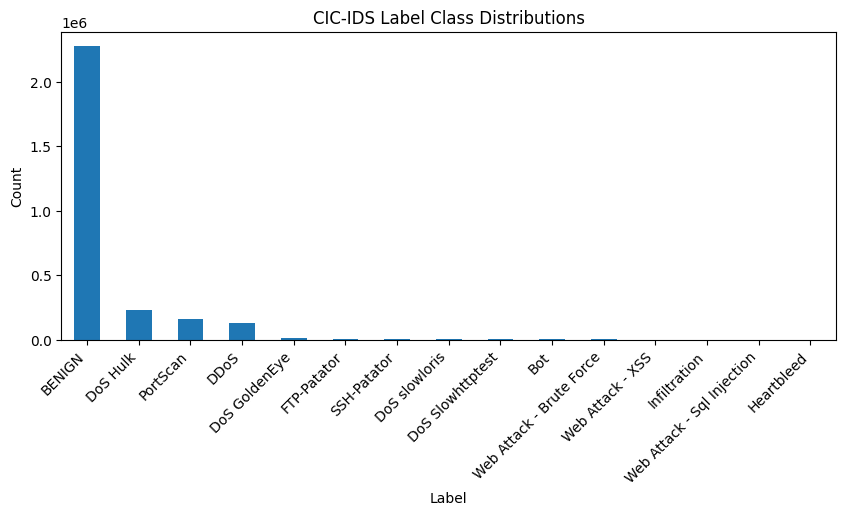

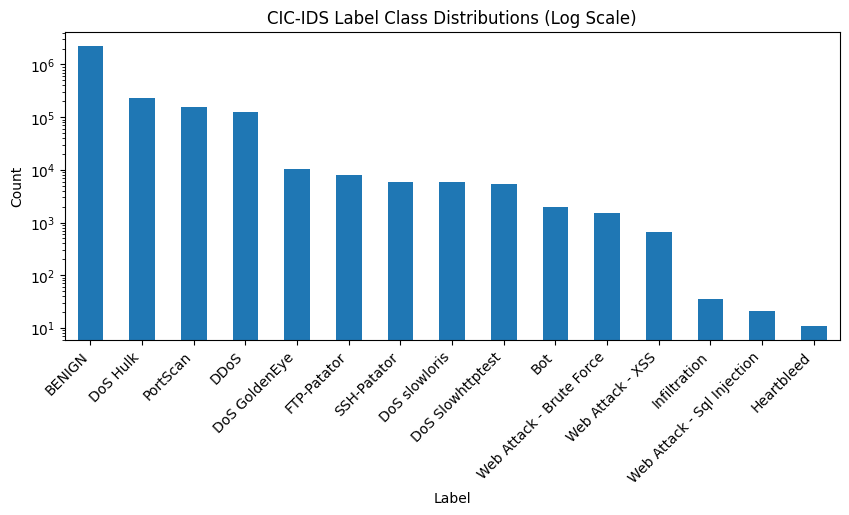

In [6]:
#replace things that could break training & drop rows without labels 
net_df.replace([np.inf, -np.inf], np.nan, inplace= True)
net_df= net_df.dropna(subset= [LABEL_COL]).reset_index(drop=True)

#plot class distributions
plt.figure(figsize=(10,4))
net_df[LABEL_COL].value_counts().plot(kind="bar")
plt.title("CIC-IDS Label Class Distributions")
plt.ylabel("Count")
plt.xticks(rotation= 45, ha="right")
plt.show()

#log scale since BENIGN dominates vs the other types
plt.figure(figsize=(10,4))
net_df[LABEL_COL].value_counts().plot(kind="bar", logy=True)
plt.title("CIC-IDS Label Class Distributions (Log Scale)")
plt.ylabel("Count")
plt.xticks(rotation= 45, ha="right")
plt.show()

### Build X/y
This helps prepare the dataset by:
- Defining the target varliable (y) 
- Seperating feature matrix (X) from non feature metadata
- Remove columns that could cause data leakage or cause model to memorize instead of learning 


In [7]:
y= net_df[LABEL_COL].astype(str)
drop_cols= [LABEL_COL]

possible_id_cols= [
    "Flow_ID", "Timestamp",
    "Src_IP", "Dst_IP", "Source_IP", "Destination_IP",
    "Src_Port", "Dst_Port", "Source_Port", "Destination_Port"
]

for c in possible_id_cols:
    if c in net_df.columns and c not in drop_cols:
        drop_cols.append(c)

GROUP_COL= "_source_file"
if GROUP_COL in net_df.columns:
    groups=net_df[GROUP_COL]
    drop_cols.append(GROUP_COL)
else:
    groups=None
X=net_df.drop(columns=drop_cols, errors= "ignore")

print("X shape:", X.shape)
print("y classes:", y.nunique())


X shape: (2830743, 77)
y classes: 15


### Train/Val/Test Split

In [8]:
#for reproducibility 
RANDOM_SEED=42
SPLIT_MODE = "stratified"  # change between group" or "stratified"
USE_GROUP_SPLIT = (SPLIT_MODE == "group") and (groups is not None)

if USE_GROUP_SPLIT:
    #split by groups and prevents leakage, does not guarantee class balance
    #trainval vs test
    gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
    trainval_idx, test_idx= next(gss1.split(X, y, groups=groups))
    X_trainval, X_test= X.iloc[trainval_idx], X.iloc[test_idx]
    y_trainval, y_test= y.iloc[trainval_idx], y.iloc[test_idx]
    groups_trainval= groups.iloc[trainval_idx]

    #train vs val 
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss2.split(X_trainval, y_trainval, groups=groups_trainval))
    X_train, X_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
    y_train, y_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    print("Using grouped split by file/day")
else:
    #keeps classes balanced 
    #stratified split
    X_trainval, X_test, y_trainval, y_test= train_test_split(
        X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
    )
    X_train, X_val, y_train, y_val= train_test_split(
        X_trainval, y_trainval, test_size=0.20, random_state=RANDOM_SEED, stratify=y_trainval
    )

    print("Using stratified random split ")

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Using stratified random split 
Train: (1811675, 77) Val: (452919, 77) Test: (566149, 77)


In [9]:
print("Train label counts:")
print(y_train.value_counts().head(20))

Train label counts:
Label
BENIGN                        1454782
DoS Hulk                       147886
PortScan                       101715
DDoS                            81937
DoS GoldenEye                    6587
FTP-Patator                      5080
SSH-Patator                      3774
DoS slowloris                    3710
DoS Slowhttptest                 3519
Bot                              1258
Web Attack - Brute Force          965
Web Attack - XSS                  418
Infiltration                       23
Web Attack - Sql Injection         14
Heartbleed                          7
Name: count, dtype: int64


In [10]:
print("\nVal label counts:")
print(y_val.value_counts().head(20))


Val label counts:
Label
BENIGN                        363695
DoS Hulk                       36972
PortScan                       25429
DDoS                           20484
DoS GoldenEye                   1647
FTP-Patator                     1270
SSH-Patator                      944
DoS slowloris                    927
DoS Slowhttptest                 880
Bot                              315
Web Attack - Brute Force         241
Web Attack - XSS                 104
Infiltration                       6
Web Attack - Sql Injection         3
Heartbleed                         2
Name: count, dtype: int64


In [11]:
print("\nTest label counts:")
print(y_test.value_counts().head(20))


Test label counts:
Label
BENIGN                        454620
DoS Hulk                       46215
PortScan                       31786
DDoS                           25606
DoS GoldenEye                   2059
FTP-Patator                     1588
SSH-Patator                     1179
DoS slowloris                   1159
DoS Slowhttptest                1100
Bot                              393
Web Attack - Brute Force         301
Web Attack - XSS                 130
Infiltration                       7
Web Attack - Sql Injection         4
Heartbleed                         2
Name: count, dtype: int64


### Preprocess & Train Model

In [12]:
numeric_features= X_train.columns.tolist()

#applies transformations by filling in missing values,
#standardizing features for mean =0 and std=1 
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

#logistic regression classification model or Random Forest
USE_MODEL = "rf"  # change between "lr" or "rf"
clf_lr= LogisticRegression(max_iter=2000)
clf_rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1, class_weight="balanced")

model = clf_lr if USE_MODEL == "lr" else clf_rf

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

#trains logistic regression on transformed data 
pipe.fit(X_train, y_train)
print("Trained:", USE_MODEL)

Trained: rf


### Validation and Test Metrics 

In [13]:
val_pred= pipe.predict(X_val)

print("Val Accuracy:", accuracy_score(y_val, val_pred))
print("\n Classification Report (VAL):")
print(classification_report(y_val, val_pred, digits=4))

Val Accuracy: 0.9970657004894915

 Classification Report (VAL):
                            precision    recall  f1-score   support

                    BENIGN     0.9997    0.9970    0.9984    363695
                       Bot     0.2931    0.9238    0.4450       315
                      DDoS     0.9998    0.9995    0.9996     20484
             DoS GoldenEye     0.9963    0.9921    0.9942      1647
                  DoS Hulk     0.9952    0.9991    0.9971     36972
          DoS Slowhttptest     0.9593    0.9898    0.9743       880
             DoS slowloris     0.9968    0.9957    0.9962       927
               FTP-Patator     0.9992    0.9976    0.9984      1270
                Heartbleed     1.0000    0.5000    0.6667         2
              Infiltration     1.0000    0.5000    0.6667         6
                  PortScan     0.9939    0.9996    0.9967     25429
               SSH-Patator     0.9989    0.9947    0.9968       944
  Web Attack - Brute Force     0.7604    0.6846    

In [16]:
test_pred= pipe.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("\nClassification report (TEST):")
print(classification_report(y_test, test_pred, digits=4))

Test Accuracy: 0.997235710033931

Classification report (TEST):
                            precision    recall  f1-score   support

                    BENIGN     0.9998    0.9971    0.9984    454620
                       Bot     0.3042    0.9466    0.4604       393
                      DDoS     0.9998    0.9995    0.9997     25606
             DoS GoldenEye     0.9985    0.9951    0.9968      2059
                  DoS Hulk     0.9950    0.9993    0.9971     46215
          DoS Slowhttptest     0.9603    0.9900    0.9749      1100
             DoS slowloris     0.9923    0.9957    0.9940      1159
               FTP-Patator     1.0000    0.9962    0.9981      1588
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    0.8571    0.9231         7
                  PortScan     0.9941    0.9996    0.9968     31786
               SSH-Patator     0.9983    0.9975    0.9979      1179
  Web Attack - Brute Force     0.7886    0.7807    